# Week 9: IPO Subscription Predictor

## Problem Statement
Predict whether an upcoming Indian Mainboard IPO will be highly oversubscribed ($\ge 10\times$) using pre-listing company and market features.

## Dataset
- **Source:** BSE & NSE Mainboard IPO Subscription Data (2025–2026)
- **Size:** 133 clean IPO records
- **Features Used:** `Issue_Amount_Cr`, `Applications`, `Has_Emp_Quota`, `Year`, `month`

## Step 0 : Importing Important Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix,classification_report,RocCurveDisplay,
                            precision_recall_fscore_support,roc_auc_score)
import shap

## Step 1: Data collection and Preprocessing

In [2]:
df_2025 = pd.read_csv('/content/Live_Mainboard_IPOs_Subscription_Status_from_BSE_and_NSE_2025_2026-08-09.csv',skiprows=2)
df_2026 = pd.read_csv('/content/Live_Mainboard_IPOs_Subscription_Status_from_BSE_and_NSE_2026_2026-08-09.csv',skiprows=2)

df = pd.concat([df_2025,df_2026],ignore_index=True)
df = df[~df['Company'].astype(str).str.contains('===')].reset_index(drop=True)
df.to_csv('Combined_IPOs_Subscription_Status.csv', index=False)

In [3]:
df

,Company,Closing Date,Total Issue Amount (Incl.Firm reservations) (Rs.cr.),QIB (x),sNII (x),bNII (x),NII (x),Retail (x),Employee (x),Shareholder (x),Others (x),Total (x),Applications,Subscription as on,ISIN,BSE Script Code,NSE Symbol
0,Gujarat Kidney & Super Speciality Ltd.,24-Dec-2025,250.8,1.06,6.68,5.25,5.73,19.04,NaN,NaN,NaN,5.21,259831,24-Dec-2025,INE0V0W01025,544666,GKSL
1,KSH International Ltd.,18-Dec-2025,710,1.12,0.8,0.26,0.44,0.91,NaN,NaN,NaN,0.87,115497,18-Dec-2025,INE987S01020,544664,KSHINTL
2,ICICI Prudential Asset Management Co.Ltd.,16-Dec-2025,10602.65,123.87,15.28,25.42,22.04,2.53,NaN,9.75,NaN,39.17,5507138,16-Dec-2025,INE346A01027,544658,ICICIAMC
3,Park Medi World Ltd.,12-Dec-2025,920,12.07,11.12,18.34,15.93,3.32,NaN,NaN,NaN,8.52,644724,12-Dec-2025,INE119201023,544645,PARKHOSPS
4,Nephrocare Health Services Ltd.,12-Dec-2025,871.05,26.82,13.46,30.43,24.77,2.36,2.81,NaN,NaN,14.08,454416,12-Dec-2025,INE428V01029,544647,NEPHROPLUS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Clean Max Enviro Energy Solutions Ltd.,25-Feb-2026,3100,2.99,0.07,0.82,0.57,0.07,0.11,NaN,NaN,0.99,37210,25-Feb-2026,INE647U01026,544717,CLEANMAX
133,Gaudium IVF & Women Health Ltd.,24-Feb-2026,165,1.62,16.73,12.71,14.05,7.6,NaN,NaN,NaN,7.27,249109,24-Feb-2026,INE0P8B01020,544709,GAUDIUMIVF
134,Shadowfax Technologies Ltd.,22-Jan-2026,1907.27,4,1.33,0.66,0.88,2.43,2.17,NaN,NaN,2.86,225616,22-Jan-2026,INE12UN01015,544685,SHADOWFAX
135,Amagi Media Labs Ltd.,16-Jan-2026,1788.62,33.13,26.29,44.24,38.26,9.54,NaN,NaN,NaN,30.24,1164157,16-Jan-2026,INE121R01077,544679,AMAGI


In [4]:
df['Closing Date'] = pd.to_datetime(df['Closing Date'], dayfirst=True)
df['Subscription as on'] = pd.to_datetime(df['Subscription as on'], dayfirst=True)
today = pd.to_datetime('today').normalize()

df['Company'] = df['Company'].astype(str).str.replace('[O]','',regex=True)
is_past_date = df['Closing Date'] < today
df = df[is_past_date].reset_index(drop=True)

df['Closing Date'] = df['Closing Date'].dt.strftime('%d-%m-%Y')
df

,Company,Closing Date,Total Issue Amount (Incl.Firm reservations) (Rs.cr.),QIB (x),sNII (x),bNII (x),NII (x),Retail (x),Employee (x),Shareholder (x),Others (x),Total (x),Applications,Subscription as on,ISIN,BSE Script Code,NSE Symbol
0,Gujarat Kidney & Super Speciality Ltd.,24-12-2025,250.8,1.06,6.68,5.25,5.73,19.04,NaN,NaN,NaN,5.21,259831,2025-12-24,INE0V0W01025,544666,GKSL
1,KSH International Ltd.,18-12-2025,710,1.12,0.8,0.26,0.44,0.91,NaN,NaN,NaN,0.87,115497,2025-12-18,INE987S01020,544664,KSHINTL
2,ICICI Prudential Asset Management Co.Ltd.,16-12-2025,10602.65,123.87,15.28,25.42,22.04,2.53,NaN,9.75,NaN,39.17,5507138,2025-12-16,INE346A01027,544658,ICICIAMC
3,Park Medi World Ltd.,12-12-2025,920,12.07,11.12,18.34,15.93,3.32,NaN,NaN,NaN,8.52,644724,2025-12-12,INE119201023,544645,PARKHOSPS
4,Nephrocare Health Services Ltd.,12-12-2025,871.05,26.82,13.46,30.43,24.77,2.36,2.81,NaN,NaN,14.08,454416,2025-12-12,INE428V01029,544647,NEPHROPLUS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Clean Max Enviro Energy Solutions Ltd.,25-02-2026,3100,2.99,0.07,0.82,0.57,0.07,0.11,NaN,NaN,0.99,37210,2026-02-25,INE647U01026,544717,CLEANMAX
133,Gaudium IVF & Women Health Ltd.,24-02-2026,165,1.62,16.73,12.71,14.05,7.6,NaN,NaN,NaN,7.27,249109,2026-02-24,INE0P8B01020,544709,GAUDIUMIVF
134,Shadowfax Technologies Ltd.,22-01-2026,1907.27,4,1.33,0.66,0.88,2.43,2.17,NaN,NaN,2.86,225616,2026-01-22,INE12UN01015,544685,SHADOWFAX
135,Amagi Media Labs Ltd.,16-01-2026,1788.62,33.13,26.29,44.24,38.26,9.54,NaN,NaN,NaN,30.24,1164157,2026-01-16,INE121R01077,544679,AMAGI


In [5]:
print(df.describe())
print(df.info())
df.isna().sum()

                  Subscription as on
count                            137
mean   2025-11-13 14:21:53.868613120
min              2025-01-08 00:00:00
25%              2025-08-13 00:00:00
50%              2025-10-07 00:00:00
75%              2026-02-27 00:00:00
max              2026-08-07 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 17 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   Company                                               137 non-null    object        
 1   Closing Date                                          137 non-null    object        
 2   Total Issue Amount (Incl.Firm reservations) (Rs.cr.)  136 non-null    object        
 3   QIB (x)                                               137 non-null    object        
 4   sNII (x)                                              

,0
Company,0
Closing Date,0
Total Issue Amount (Incl.Firm reservations) (Rs.cr.),1
QIB (x),0
sNII (x),2
bNII (x),2
NII (x),0
Retail (x),2
Employee (x),74
Shareholder (x),131


In [6]:
df=df.drop(columns=['Company','Others (x)','Shareholder (x)','ISIN','BSE Script Code','NSE Symbol','Subscription as on'])
df['Had Employee Quota'] = df['Employee (x)'].notna().astype(int)
df['Employee (x)'].fillna(0,inplace=True)
df.isna().sum()

/tmp/ipykernel_3237/2560615592.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Employee (x)'].fillna(0,inplace=True)


,0
Closing Date,0
Total Issue Amount (Incl.Firm reservations) (Rs.cr.),1
QIB (x),0
sNII (x),2
bNII (x),2
NII (x),0
Retail (x),2
Employee (x),0
Total (x),0
Applications,1


In [7]:
df.dropna(inplace=True)
numeric_columns = ['Total Issue Amount (Incl.Firm reservations) (Rs.cr.)','QIB (x)',
                   'sNII (x)','bNII (x)','NII (x)','Retail (x)','Employee (x)',
                   'Total (x)','Applications']
for col in numeric_columns:
  df[col] = pd.to_numeric(df[col],errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 135 entries, 0 to 136
Data columns (total 11 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Closing Date                                          135 non-null    object 
 1   Total Issue Amount (Incl.Firm reservations) (Rs.cr.)  135 non-null    float64
 2   QIB (x)                                               135 non-null    float64
 3   sNII (x)                                              135 non-null    float64
 4   bNII (x)                                              135 non-null    float64
 5   NII (x)                                               135 non-null    float64
 6   Retail (x)                                            135 non-null    float64
 7   Employee (x)                                          135 non-null    float64
 8   Total (x)                                             135 non-nul

## Step 2 : EDA

In [8]:
df['Year'] = pd.to_datetime(df['Closing Date']).dt.year
df['month'] = pd.to_datetime(df['Closing Date']).dt.month

df['highly_oversubscribed'] = (df['Total (x)'] >= 10.0).astype(int)
df.drop(columns=['Closing Date'],inplace=True)
column_mapping = {
    'Total Issue Amount (Incl.Firm reservations) (Rs.cr.)': 'Issue_Amount_Cr',
    'Had Employee Quota': 'Has_Emp_Quota',
}
df.rename(columns=column_mapping, inplace=True)

/tmp/ipykernel_3237/1904842859.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Year'] = pd.to_datetime(df['Closing Date']).dt.year
/tmp/ipykernel_3237/1904842859.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['month'] = pd.to_datetime(df['Closing Date']).dt.month


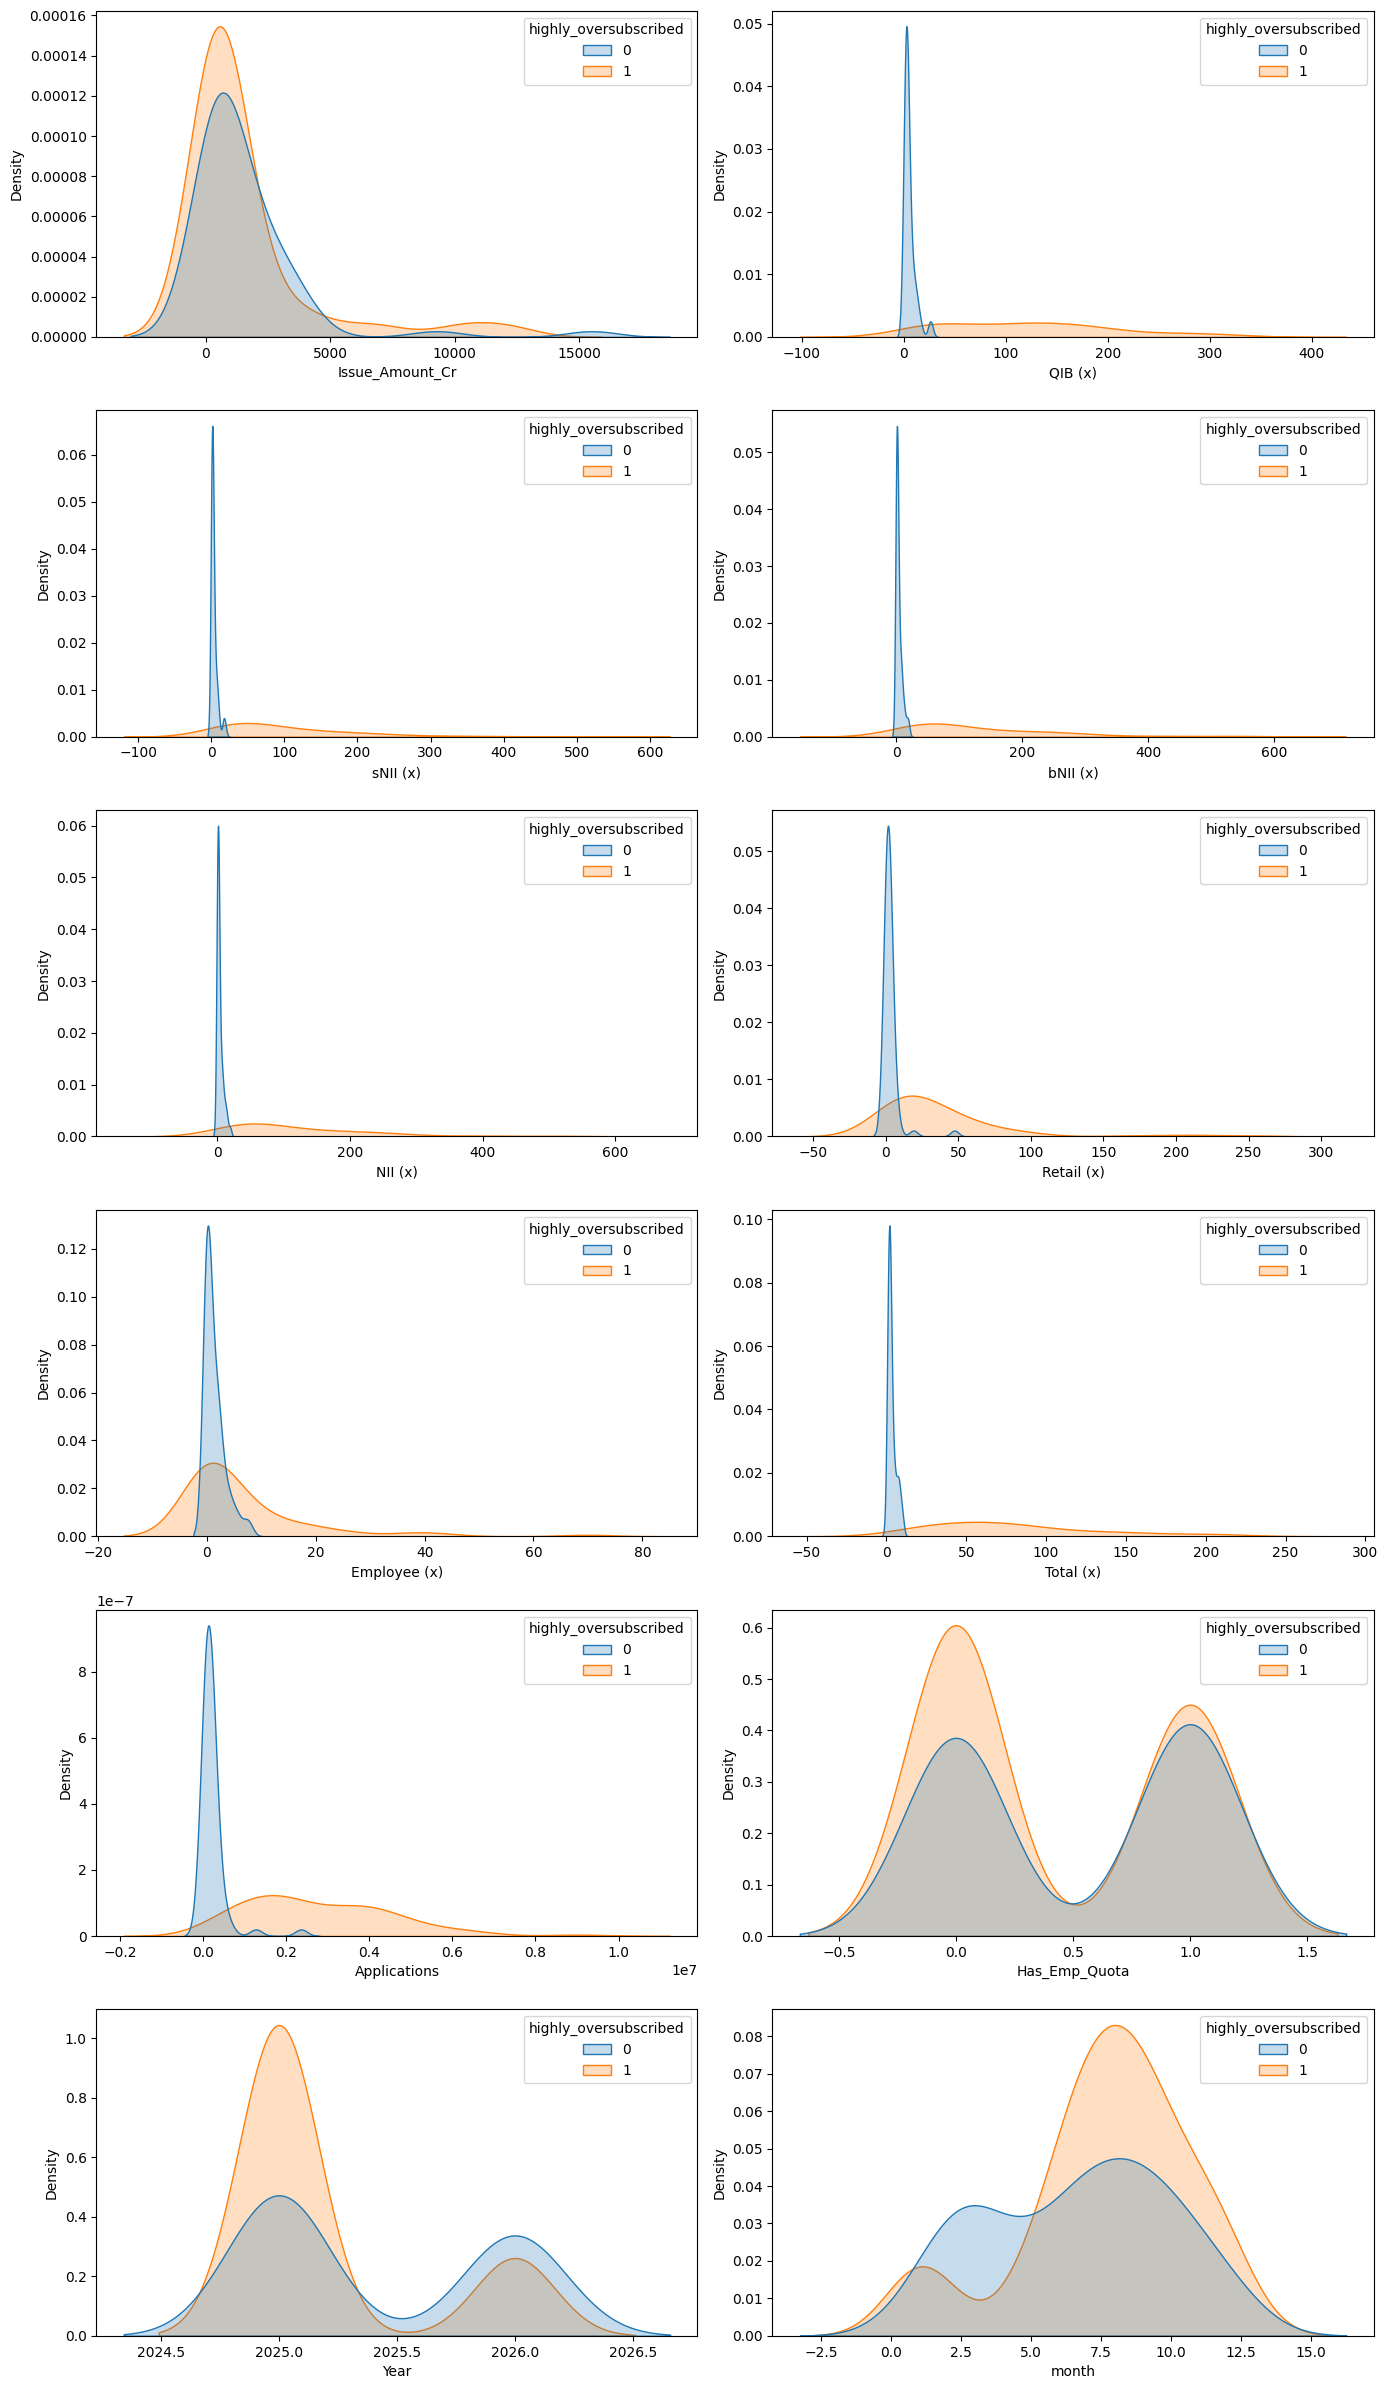

In [9]:
numeric_columns = df.drop(columns=['highly_oversubscribed']).select_dtypes(include='number').columns
numeric_columns

fig,ax = plt.subplots(nrows=6,ncols=2,figsize=(14,24))
ax = ax.flatten()
for i,col in enumerate(numeric_columns):
  sns.kdeplot(data=df,x=col,ax=ax[i],hue='highly_oversubscribed',fill=True)

for j in range(len(numeric_columns), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

In [11]:
df.drop(columns=['Total (x)','QIB (x)','Employee (x)',
                   'Total (x)','sNII (x)','bNII (x)','NII (x)','Retail (x)','Applications'],inplace=True)

In [12]:
df

,Issue_Amount_Cr,Has_Emp_Quota,Year,month,highly_oversubscribed
0,250.80,0,2025,12,0
1,710.00,0,2025,12,0
2,10602.65,0,2025,12,1
3,920.00,0,2025,12,0
4,871.05,1,2025,12,1
...,...,...,...,...,...
132,3100.00,1,2026,2,0
133,165.00,0,2026,2,0
134,1907.27,1,2026,1,0
135,1788.62,0,2026,1,1


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
y = df['highly_oversubscribed']
X= df.drop(columns=['highly_oversubscribed'])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 3: Model Tuning & Comparison

In [16]:
models = {
    'SVC': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2]
        }
    }
}

results = []

for name, config in models.items():
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test_scaled)

    # Calculate required metrics
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')

    results.append({
        'Model': name,
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1 Score': round(f1, 3),
        'Best Params': grid.best_params_
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1 Score,Best Params
0,SVC,0.600,0.800,0.686,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}"
1,RandomForest,0.526,0.667,0.588,"{'max_depth': 5, 'min_samples_split': 2, 'n_es..."
2,XGBoost,0.550,0.733,0.629,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


## Step 4: Training Model as per Best parameters for XGBoost

In [17]:
xgb_params = results_df.loc[results_df['Model'] == 'XGBoost', 'Best Params'].values[0]
xgb = XGBClassifier(**xgb_params,random_state=42,eval_metric='logloss')

xgb.fit(X_train_scaled,y_train)
y_pred = xgb.predict(X_test_scaled)
y_pred_proba = xgb.predict_proba(X_test_scaled)

              precision    recall  f1-score   support

           0       0.43      0.25      0.32        12
           1       0.55      0.73      0.63        15

    accuracy                           0.52        27
   macro avg       0.49      0.49      0.47        27
weighted avg       0.50      0.52      0.49        27



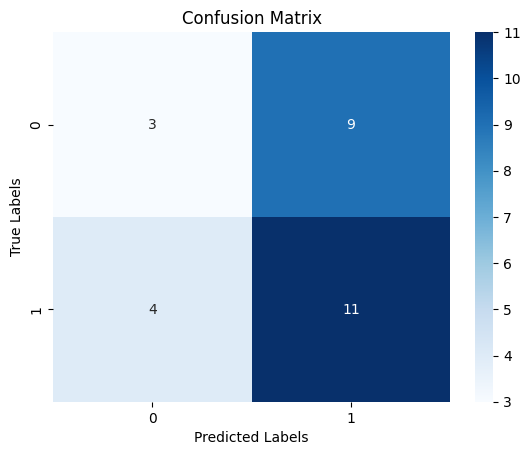

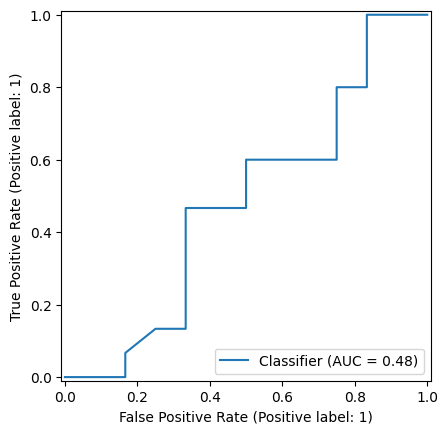

In [18]:
print(classification_report(y_pred=y_pred,y_true=y_test))
cm = confusion_matrix(y_pred=y_pred,y_true=y_test)
sns.heatmap(cm, annot=True,fmt="d",cmap='Blues')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix')
RocCurveDisplay.from_predictions(y_test,y_pred_proba[:,1])
plt.show()

## Step 5: Feature Importance Analysis
Plot Native Importance, Permutation Importance, and SHAP side-by-side using fixed figure dimensions so the bars stay legible:

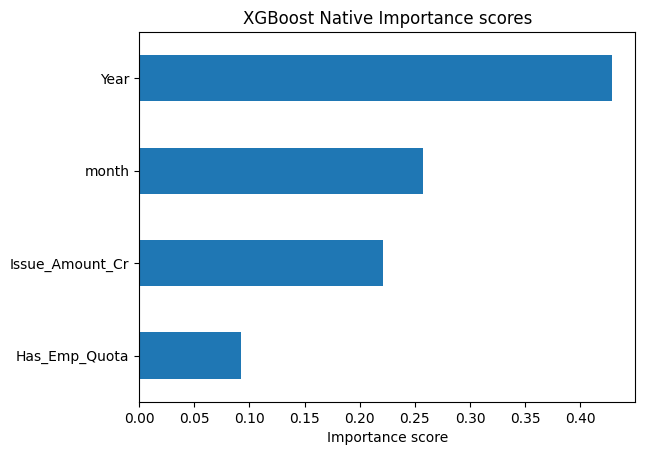

In [19]:
feature_names = X.columns

xgb_importance = pd.Series(xgb.feature_importances_,index=feature_names).sort_values(ascending=True)
xgb_importance.plot(kind='barh')
plt.xlabel("Importance score")
plt.title("XGBoost Native Importance scores")
plt.show()

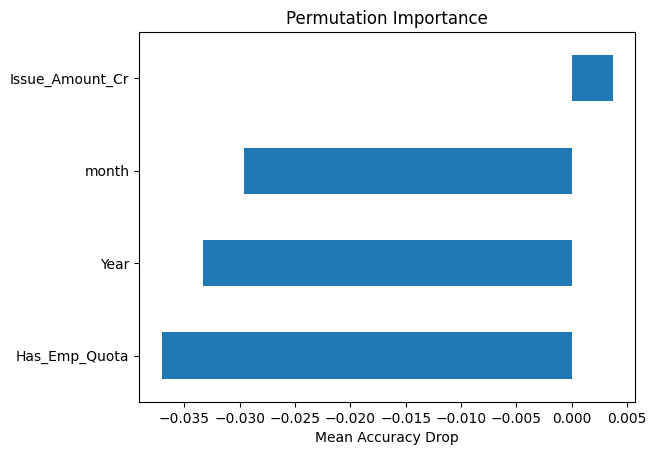

In [20]:
perm_results = permutation_importance(xgb,X_test_scaled,y_test,n_repeats=10,scoring='accuracy',
                                      random_state=42)
perm_importance = pd.Series(perm_results.importances_mean,index=feature_names).sort_values(ascending=True)
perm_importance.plot(kind='barh')
plt.title('Permutation Importance')
plt.xlabel('Mean Accuracy Drop')
plt.show()

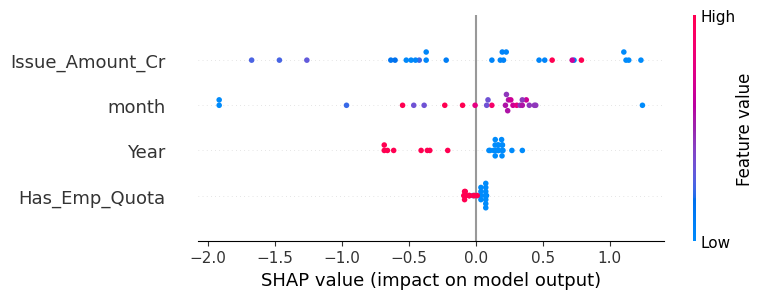

In [21]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

### Feature Importance Analysis & Business Logic (Revised — Honest Feature Set)

**Note on an earlier version of this notebook:** an earlier draft included `Applications` and per-category subscription multiples (`QIB`, `NII`, `Retail`, etc.) as model features, which produced misleadingly strong performance (~89% accuracy). Those columns are only known *during or at the close* of an IPO's subscription window — using them to "predict" oversubscription is closer to describing an outcome that has already happened than genuinely forecasting one. This version keeps only features that are actually available *before* an IPO's subscription period opens: `Issue_Amount_Cr`, `Has_Emp_Quota`, `Year`, `month`.

With this honest, pre-listing-only feature set, feature importance shifts substantially:

* **1. `Year` (~40%) and `month` (~29%) — together nearly 70% of the model's decisions.**
  This most likely reflects broad IPO-market-cycle effects (e.g., overall sentiment differing between 2025 and 2026, or seasonal listing patterns) rather than anything specific to an individual company or issue.

* **2. `Issue_Amount_Cr` (~20%):**
  Smaller issue sizes still show *some* association with higher oversubscription multiples — consistent with the earlier (leaky) version's finding — but the signal is far weaker in isolation, without the subscription-window features propping it up.

* **3. `Has_Emp_Quota` (~11%, weakest signal):**
  Whether a company offers an employee reservation tranche carries the least independent predictive value of the four features.

# Final Business Insights (Revised)

With only genuinely pre-listing information, this model performs **at or below the majority-class baseline** (~48–52% accuracy vs. a 55.5% baseline from always predicting "highly oversubscribed"). In other words: **issue size, employee quota status, and listing year/month alone do not reliably predict whether an IPO will be highly oversubscribed.**

This is a meaningful finding, not a failed experiment. It shows that the strong performance in earlier iterations of this notebook (~89% accuracy) was driven almost entirely by information that only becomes available once an IPO's subscription window is already open or closed (`Applications` count, and the QIB/NII/Retail subscription multiples) — not by anything genuinely knowable in advance.

**What this means in practice:** a genuinely predictive, pre-listing IPO oversubscription model would need signals not present in this dataset, such as:
- Grey market premium (GMP) trends in the days before listing
- Anchor investor allocation strength (typically announced ~1 day before the issue opens to the public)
- Sector-level market sentiment
- Promoter/company track record or prior listings

These are the natural next data sources to pursue if this project were extended further — and connect directly back to the `sector` and `listing_gain_pct` columns the original task specification called for, which weren't available in the raw scraped data used here.
